In [44]:
!pip install -q kagglehub
!pip install nltk
%pip install wordcloud


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
from pathlib import Path
import kagglehub

# Download dataset
dataset_dir = kagglehub.dataset_download(
    "jp797498e/twitter-entity-sentiment-analysis"
)

dataset_path = Path(dataset_dir)

# Load training data
train_df = pd.read_csv(
    dataset_path / "twitter_training.csv",
    header=None,
    names=["ID", "Entity", "Sentiment", "Text"]
)

train_df.head()

c:\Users\Abdul Ahad\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.99M/1.99M [00:01<00:00, 1.96MB/s]

Extracting files...


,ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [11]:
train_df.head()

,ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [12]:
train_df.columns

Index(['ID', 'Entity', 'Sentiment', 'Text'], dtype='str')

In [15]:
new_headers = {
    train_df.columns[0]: "Tweet_ID",
    train_df.columns[1]: "Entity",
    train_df.columns[2]: "Sentiment",
    train_df.columns[3]: "Tweet"
}

train_df.rename(columns=new_headers, inplace=True)

train_df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [16]:
train_df.info

<bound method DataFrame.info of        Tweet_ID       Entity Sentiment  \
0          2401  Borderlands  Positive   
1          2401  Borderlands  Positive   
2          2401  Borderlands  Positive   
3          2401  Borderlands  Positive   
4          2401  Borderlands  Positive   
...         ...          ...       ...   
74677      9200       Nvidia  Positive   
74678      9200       Nvidia  Positive   
74679      9200       Nvidia  Positive   
74680      9200       Nvidia  Positive   
74681      9200       Nvidia  Positive   

                                                   Tweet  
0      im getting on borderlands and i will murder yo...  
1      I am coming to the borders and I will kill you...  
2      im getting on borderlands and i will kill you ...  
3      im coming on borderlands and i will murder you...  
4      im getting on borderlands 2 and i will murder ...  
...                                                  ...  
74677  Just realized that the Windows partition of

In [17]:
train_df.describe

<bound method NDFrame.describe of        Tweet_ID       Entity Sentiment  \
0          2401  Borderlands  Positive   
1          2401  Borderlands  Positive   
2          2401  Borderlands  Positive   
3          2401  Borderlands  Positive   
4          2401  Borderlands  Positive   
...         ...          ...       ...   
74677      9200       Nvidia  Positive   
74678      9200       Nvidia  Positive   
74679      9200       Nvidia  Positive   
74680      9200       Nvidia  Positive   
74681      9200       Nvidia  Positive   

                                                   Tweet  
0      im getting on borderlands and i will murder yo...  
1      I am coming to the borders and I will kill you...  
2      im getting on borderlands and i will kill you ...  
3      im coming on borderlands and i will murder you...  
4      im getting on borderlands 2 and i will murder ...  
...                                                  ...  
74677  Just realized that the Windows partition 

In [18]:
rows, cols = train_df.shape

print(f"Rows : {rows}")
print(f"Columns : {cols}")

Rows : 74682
Columns : 4


In [20]:
df = train_df.copy()

In [21]:
df.isnull().sum()

Tweet_ID       0
Entity         0
Sentiment      0
Tweet        686
dtype: int64

In [22]:
df.dropna(inplace=True)

df.isnull().sum()

Tweet_ID     0
Entity       0
Sentiment    0
Tweet        0
dtype: int64

In [23]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicate Rows: 2340


In [24]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [25]:
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [26]:
df["Sentiment"].value_counts()

Sentiment
Negative      21698
Positive      19713
Neutral       17708
Irrelevant    12537
Name: count, dtype: int64

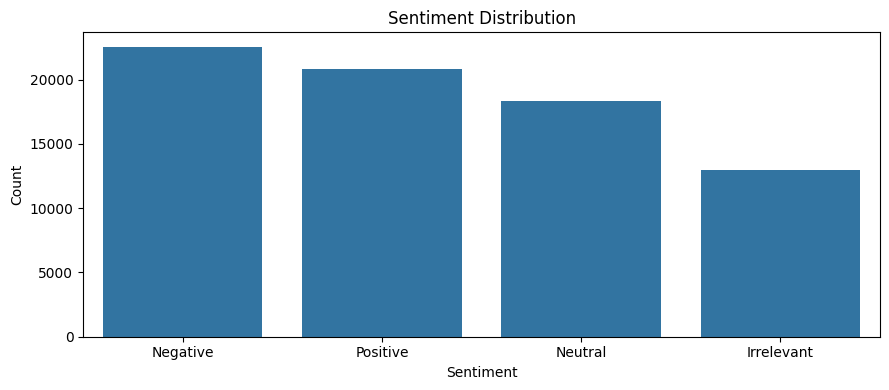

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_order = (
    train_df["Sentiment"]
    .value_counts()
    .index
)

fig, ax = plt.subplots(figsize=(9, 4))

sns.countplot(
    data=train_df,
    x="Sentiment",
    order=sentiment_order,
    ax=ax
)

ax.set_title("Sentiment Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [31]:
import nltk

required_packages = ["stopwords", "wordnet", "omw-1.4"]

for package in required_packages:
    nltk.download(package, quiet=True)

print("NLTK resources downloaded successfully.")

NLTK resources downloaded successfully.


In [32]:
selected_columns = ("Tweet", "Sentiment")

train_df = train_df.loc[:, selected_columns].copy()

train_df.head()

,Tweet,Sentiment
0,im getting on borderlands and i will murder yo...,Positive
1,I am coming to the borders and I will kill you...,Positive
2,im getting on borderlands and i will kill you ...,Positive
3,im coming on borderlands and i will murder you...,Positive
4,im getting on borderlands 2 and i will murder ...,Positive


In [33]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

In [34]:
import re
import string

def clean_text(text):

    cleaned = str(text).casefold()

    cleaned = re.sub(r"(https?://\S+|www\.\S+)", "", cleaned)
    cleaned = re.sub(r"@\w+", "", cleaned)
    cleaned = cleaned.replace("#", "")
    cleaned = re.sub(r"\d+", "", cleaned)

    cleaned = cleaned.translate(
        str.maketrans("", "", string.punctuation)
    )

    tokens = re.split(r"\s+", cleaned.strip())

    filtered_tokens = []

    for token in tokens:
        if token and token not in stop_words:
            filtered_tokens.append(
                lemmatizer.lemmatize(token)
            )

    return " ".join(filtered_tokens)

In [38]:
display(
    train_df.filter(items=["Tweet", "Clean_Tweet"]).head(10)
)

,Tweet
0,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...
2,im getting on borderlands and i will kill you ...
3,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...
5,im getting into borderlands and i can murder y...
6,So I spent a few hours making something for fu...
7,So I spent a couple of hours doing something f...
8,So I spent a few hours doing something for fun...
9,So I spent a few hours making something for fu...


In [39]:
processed_tweets = train_df["Tweet"].map(clean_text)

train_df.insert(
    len(train_df.columns),
    "Clean_Tweet",
    processed_tweets
)

train_df.head()

,Tweet,Sentiment,Clean_Tweet
0,im getting on borderlands and i will murder yo...,Positive,im getting borderland murder
1,I am coming to the borders and I will kill you...,Positive,coming border kill
2,im getting on borderlands and i will kill you ...,Positive,im getting borderland kill
3,im coming on borderlands and i will murder you...,Positive,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,Positive,im getting borderland murder


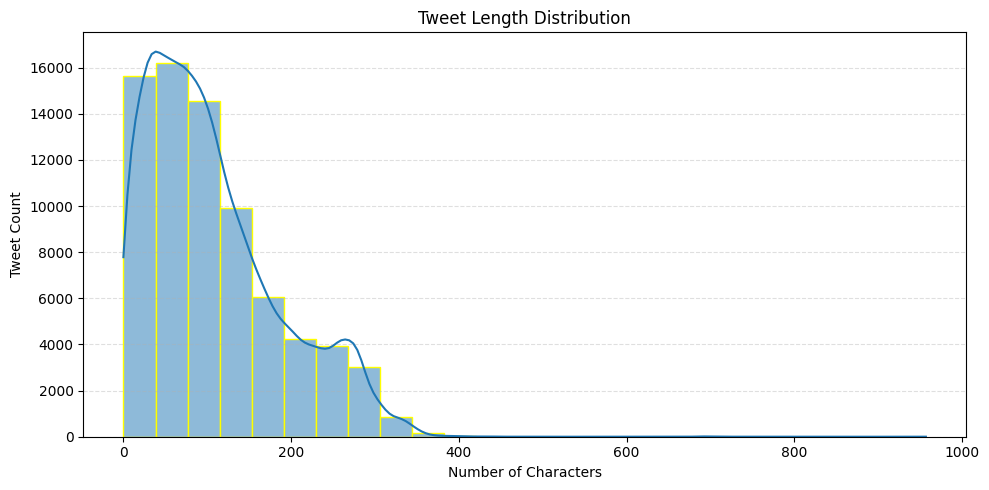

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate tweet length
train_df = train_df.assign(
    Tweet_Length=train_df["Tweet"].fillna("").str.len()
)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=train_df,
    x="Tweet_Length",
    bins=25,
    kde=True,
    edgecolor="yellow"
)

plt.title("Tweet Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Tweet Count")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [45]:
%pip install wordcloud matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


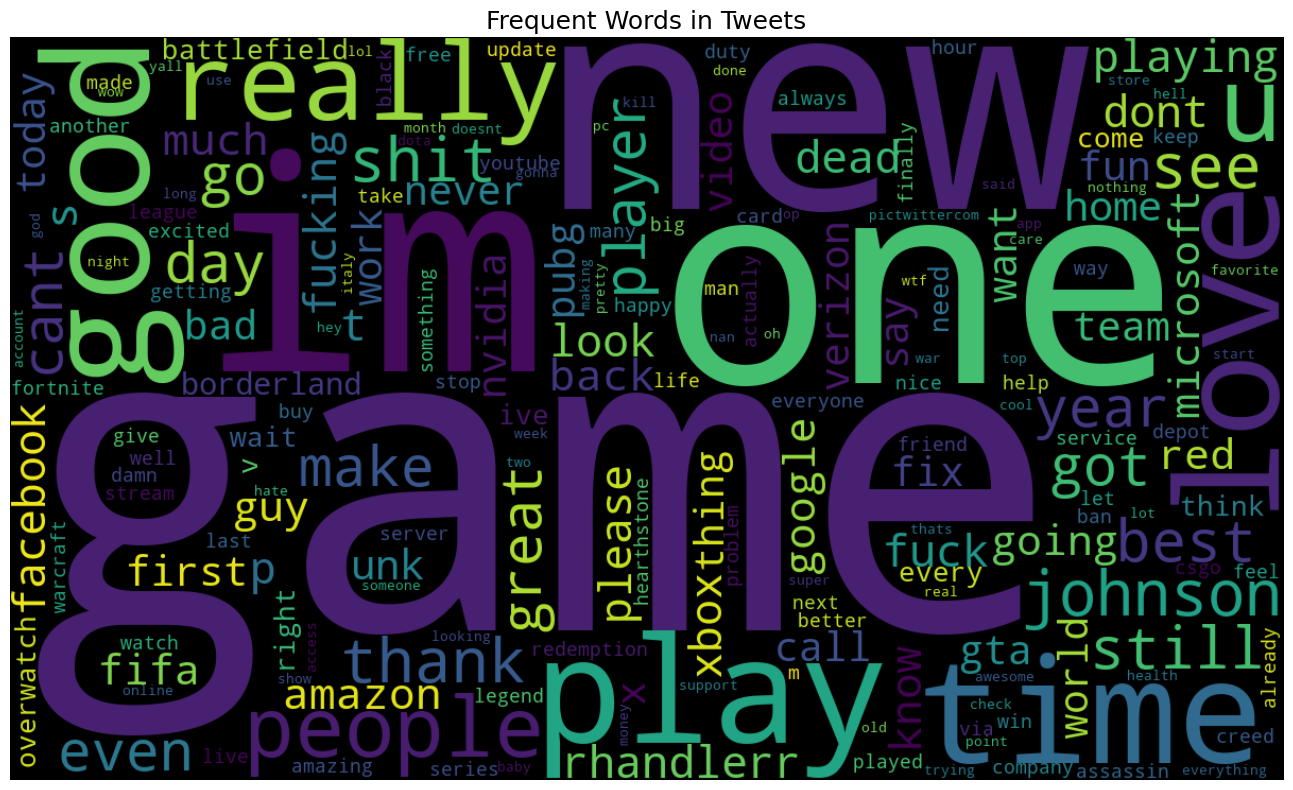

In [46]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(train_df["Clean_Tweet"].dropna())

wc = WordCloud(
    width=1200,
    height=700,
    background_color="black",
    colormap="viridis",
    max_words=200,
    contour_color="white",
    contour_width=2,
    collocations=False,
    random_state=42
)

cloud = wc.generate(all_text)

plt.figure(figsize=(15, 8))
plt.imshow(cloud, interpolation="bilinear")
plt.title("Frequent Words in Tweets", fontsize=18)
plt.axis("off")
plt.tight_layout()
plt.show()

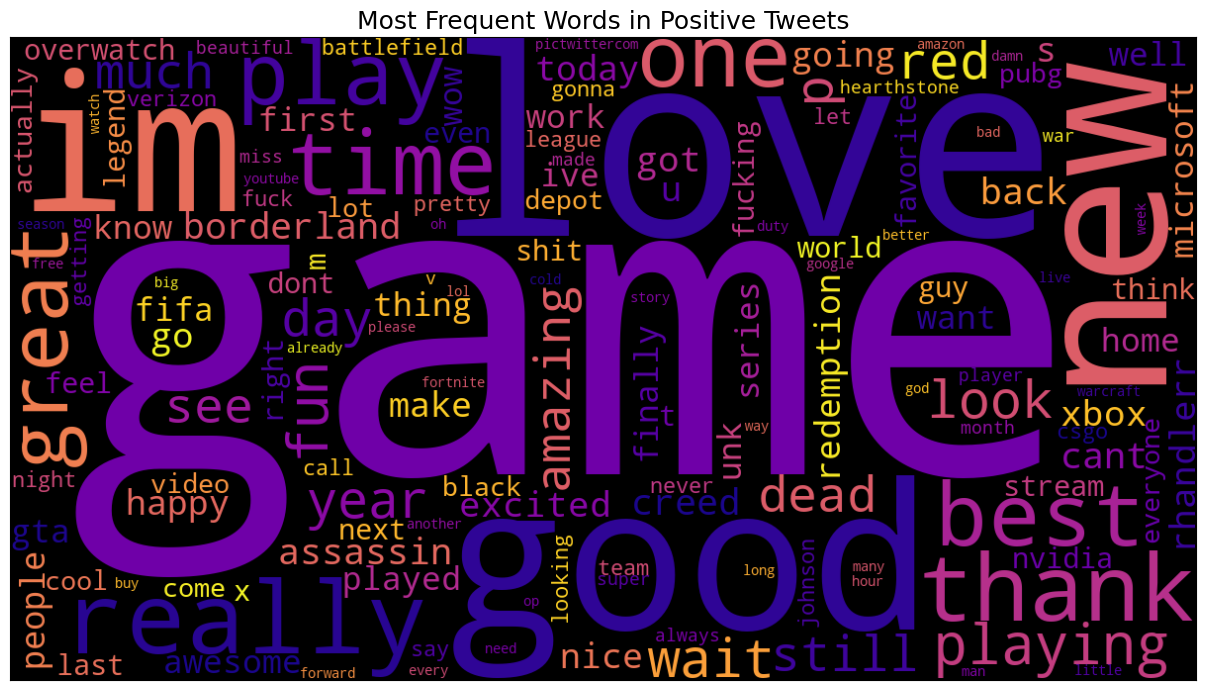

In [47]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(
    train_df.loc[
        train_df["Sentiment"].eq("Positive"),
        "Clean_Tweet"
    ].dropna()
)

positive_cloud = WordCloud(
    width=1200,
    height=650,
    background_color="black",
    colormap="plasma",
    max_words=150,
    contour_width=2,
    contour_color="white",
    random_state=7,
    collocations=False
).generate(positive_text)

plt.figure(figsize=(15, 7))

plt.imshow(positive_cloud, interpolation="bilinear")

plt.title("Most Frequent Words in Positive Tweets", fontsize=18)

plt.xticks([])
plt.yticks([])

plt.tight_layout()

plt.show()

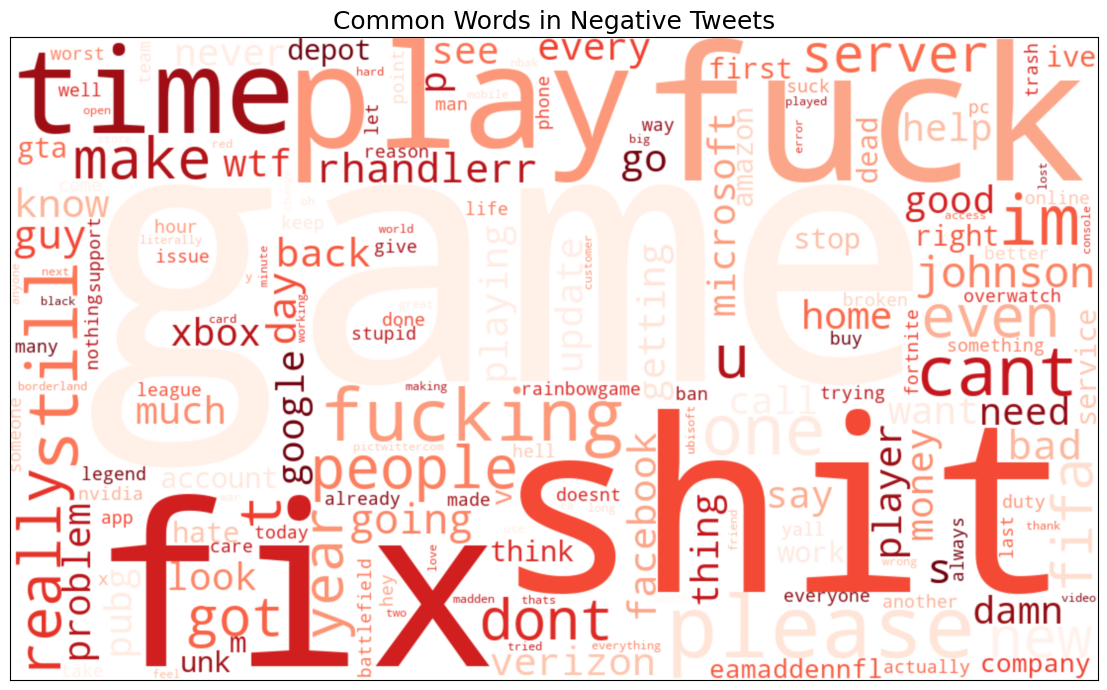

In [49]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

negative_text = " ".join(
    train_df.loc[
        train_df["Sentiment"].eq("Negative"),
        "Clean_Tweet"
    ].dropna()
)

negative_cloud = WordCloud(
    width=1100,
    height=650,
    background_color="white",
    colormap="Reds",
    max_words=180,
    contour_color="black",
    contour_width=1,
    prefer_horizontal=0.8,
    random_state=25,
    collocations=False
).generate(negative_text)

plt.figure(figsize=(15, 7))

plt.imshow(negative_cloud, interpolation="bicubic")

plt.title("Common Words in Negative Tweets", fontsize=18)

plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

In [50]:
from collections import Counter
import pandas as pd

all_words = " ".join(train_df["Clean_Tweet"].dropna()).split()

word_counts = Counter(all_words)

common_df = pd.DataFrame(
    word_counts.most_common(15),
    columns=["Word", "Count"]
)

display(common_df)

,Word,Count
0,game,10346
1,like,4959
2,get,4368
3,im,3828
4,one,3713
5,play,3613
6,good,3563
7,time,3492
8,love,3320
9,really,3260


In [52]:
print(common_df.columns)

Index(['Word', 'Count'], dtype='str')


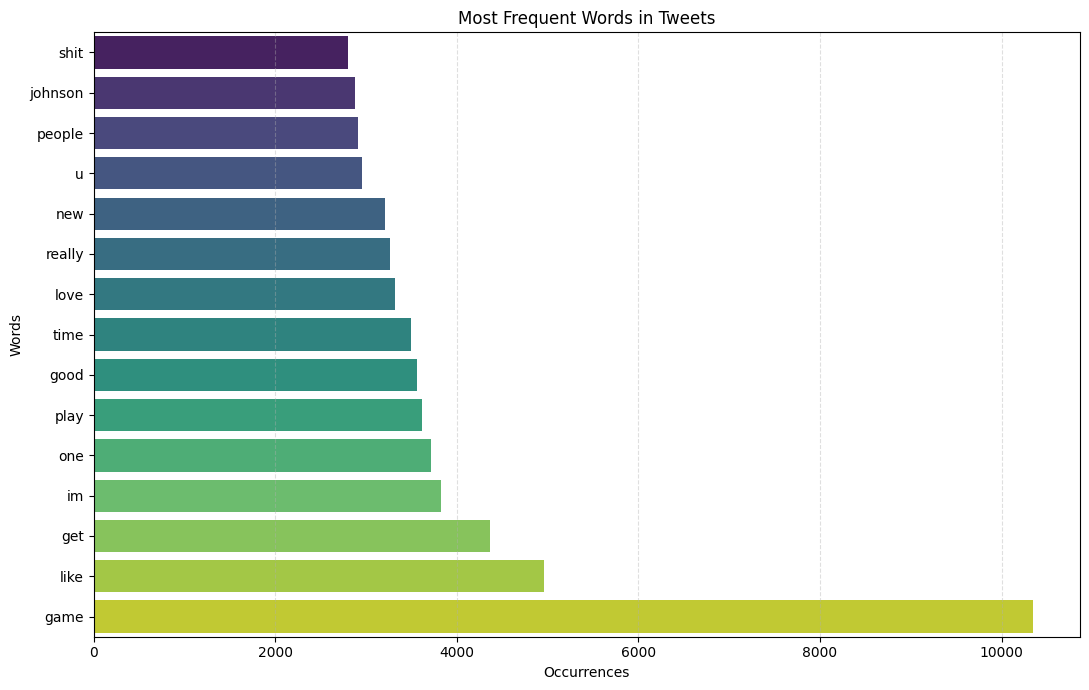

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

top_words = common_df.sort_values(
    by="Count",
    ascending=True
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_words,
    x="Count",
    y="Word",
    hue="Word",
    palette="viridis",
    legend=False
)

plt.title("Most Frequent Words in Tweets")
plt.xlabel("Occurrences")
plt.ylabel("Words")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [54]:
df['Sentiment'] = df['Sentiment'].replace({
    'Negative':0,
    'Neutral':1,
    'Positive':2,
    'Irrelevant':3
})

df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,2,im getting on borderlands and i will murder yo...
1,2401,Borderlands,2,I am coming to the borders and I will kill you...
2,2401,Borderlands,2,im getting on borderlands and i will kill you ...
3,2401,Borderlands,2,im coming on borderlands and i will murder you...
4,2401,Borderlands,2,im getting on borderlands 2 and i will murder ...


In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    lowercase=True,
    sublinear_tf=True
)

features = vectorizer.fit_transform(
    train_df["Clean_Tweet"].fillna("")
)

labels = train_df["Sentiment"].copy()

X = features
y = labels

In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=4500,
    min_df=2,
    strip_accents="unicode"
)

corpus = train_df["Clean_Tweet"].fillna("").tolist()

X = vectorizer.fit_transform(corpus)

y = train_df.loc[:, "Sentiment"].values

In [62]:
print(type(X))
print(type(y))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'pandas.arrays.ArrowStringArray'>


In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(train_df["Clean_Tweet"].fillna(""))

y = train_df["Sentiment"]

In [65]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

y_pred = model.predict(X_test)

In [68]:
print(type(X))
print(type(y))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'pandas.Series'>


In [69]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(
    y_true=y_test,
    y_pred=y_pred
)

print(f"Model Accuracy: {accuracy:.4f}")

report = classification_report(
    y_test,
    y_pred,
    digits=4
)

print("\nClassification Report")
print("-" * 60)
print(report)

Model Accuracy: 0.6744

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

  Irrelevant     0.6520    0.4907    0.5600      2592
    Negative     0.7178    0.7599    0.7383      4519
     Neutral     0.6051    0.6510    0.6272      3596
    Positive     0.6986    0.7156    0.7070      4230

    accuracy                         0.6744     14937
   macro avg     0.6684    0.6543    0.6581     14937
weighted avg     0.6738    0.6744    0.6717     14937



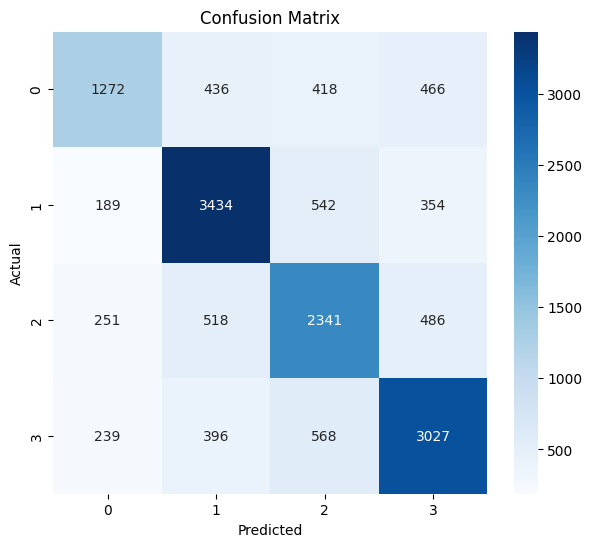

In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

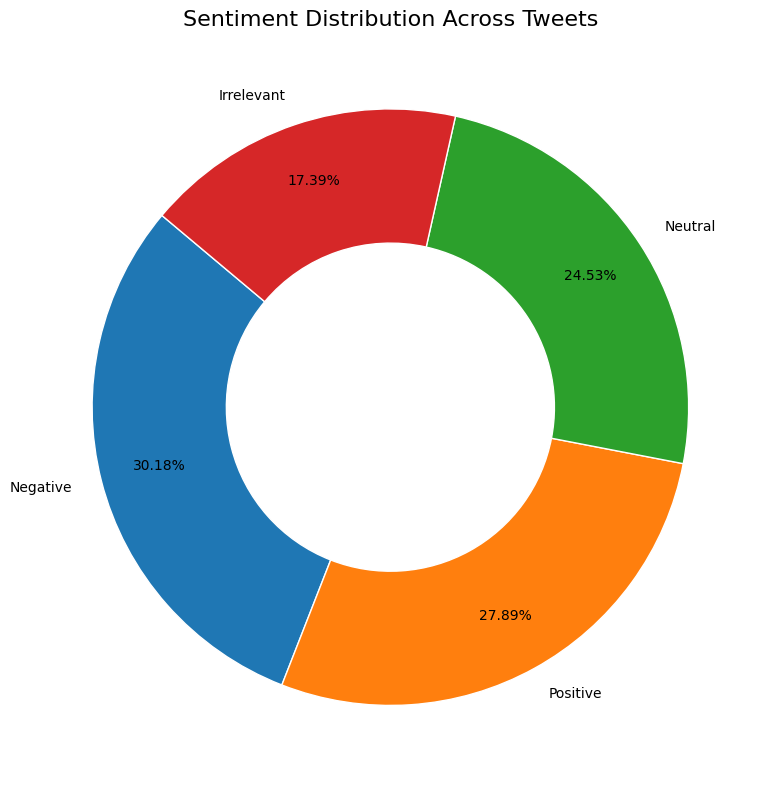

In [71]:
import matplotlib.pyplot as plt

sentiment_counts = (
    train_df["Sentiment"]
    .value_counts()
)

plt.figure(figsize=(8, 8))

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct="%.2f%%",
    startangle=140,
    pctdistance=0.8,
    wedgeprops={
        "width": 0.45,
        "edgecolor": "white"
    }
)

plt.title("Sentiment Distribution Across Tweets", fontsize=16)

plt.tight_layout()
plt.show()

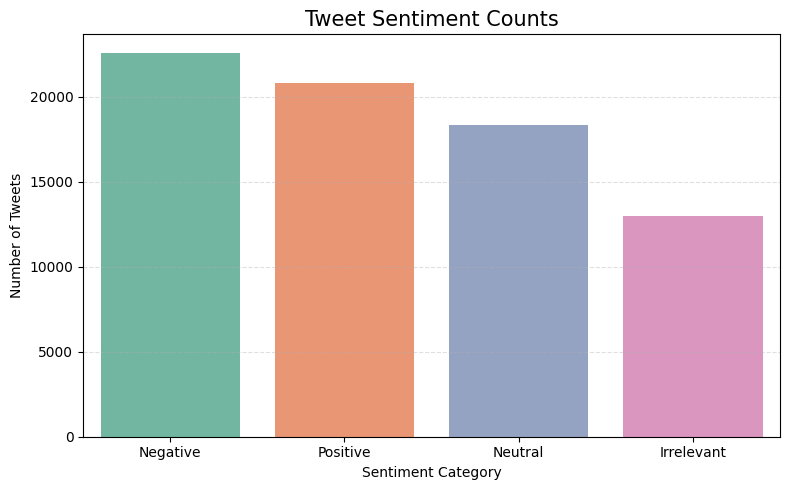

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = (
    train_df["Sentiment"]
    .value_counts()
    .reset_index()
)

counts.columns = ["Sentiment", "Total"]

plt.figure(figsize=(8, 5))

sns.barplot(
    data=counts,
    x="Sentiment",
    y="Total",
    hue="Sentiment",
    palette="Set2",
    legend=False
)

plt.title("Tweet Sentiment Counts", fontsize=15)
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Tweets")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [73]:
def predict_sentiment(text):

    processed_text = clean_text(text)

    transformed_text = vectorizer.transform([processed_text])

    predicted_label = model.predict(transformed_text).item()

    sentiment_map = {
        0: "Negative",
        1: "Neutral",
        2: "Positive",
        3: "Irrelevant"
    }

    result = sentiment_map.get(predicted_label, "Unknown")

    print(f"Predicted Sentiment: {result}")

    return result

In [74]:
predict_sentiment(
    "This phone is amazing. I love its camera and battery life!"
)

Predicted Sentiment: Unknown


'Unknown'

In [75]:
predict_sentiment(
    "Worst product ever. Completely disappointed."
)

Predicted Sentiment: Unknown


'Unknown'

In [76]:
def predict_sentiment(text):

    cleaned_text = clean_text(text)

    vector = tfidf.transform([cleaned_text])

    prediction = lr.predict(vector)[0]

    print("Predicted Sentiment:", prediction)

    return prediction

In [78]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(train_df["Clean_Tweet"])

y = train_df["Sentiment"]

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [80]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [81]:
def predict_sentiment(text):

    cleaned = clean_text(text)

    vector = tfidf.transform([cleaned])

    prediction = lr.predict(vector)[0]

    print("Predicted Sentiment:", prediction)

predict_sentiment("This phone is amazing. I love its camera and battery life!")

Predicted Sentiment: Positive


In [82]:
predict_sentiment(
    "This phone is amazing. I love its camera and battery life!"
)

Predicted Sentiment: Positive
